In [7]:
import numpy as np
import GPy
from matplotlib import pyplot as plt
import pandas as pd
from scipy import interpolate
import random

In [2]:
putts = pd.read_csv("/Users/federicadomecq/Documents/golfModeL47-1/PART 1/broadiedata/strokes_on_green_feet_broadie.csv")
columns = putts.columns
print(columns)

Index(['Distance (feet)', 'Green'], dtype='object')


# Interpolating expected putts

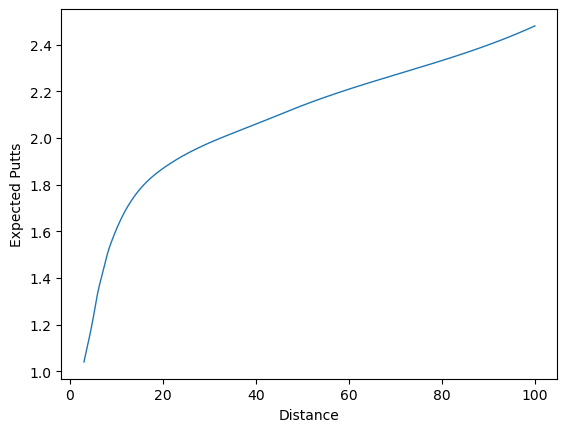

In [3]:
dist, avg_putts = putts["Distance (feet)"], putts["Green"]
expected_putts = interpolate.interp1d(dist, avg_putts, kind = "cubic", fill_value = "extrapolate")
x_true = np.linspace(min(dist), max(dist) + 10, 500)
y_true = expected_putts(x_true)
plt.plot(x_true, y_true, label = "true function", linewidth = 1 )
plt.xlabel("Distance")
plt.ylabel("Expected Putts")
plt.show()

# Simulating Fake Data

Generating data. The average number of events in a PGA tour season is 39. So generating 35 different observations max at any point... fewer observations the longer the putt.
Simulating recorded tournament average putts at different distances (feet).
For each distance $d\in [1,100]$ I'm going to generate a number of samples:
- $n_d = 35, d \leq 30 $
- $n_d$ decreases smoothly as $d \to 100$

Defining sampling frequency:

Text(0, 0.5, 'Average putts to hole out')

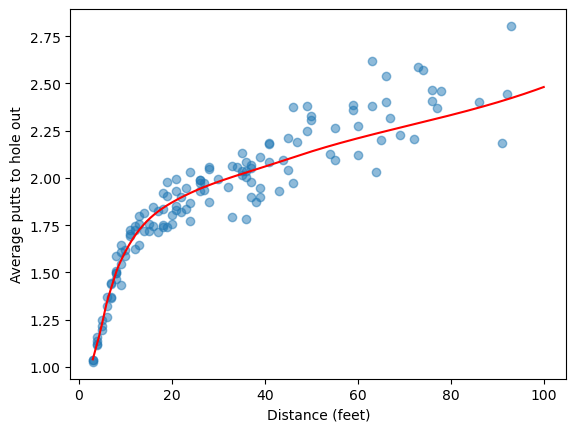

In [4]:
random.seed(47)
def samples_at(dist):
        decay_rate = 0.04  # tweak this!
        p = 1 / (1 + np.exp(decay_rate * (dist - 20))) 
        return np.random.binomial(n=5, p=p)
    
def noise_sd(d):
    return min(0.0028 * d + 0.02, 1.2)

simulated_averages = []
for distance in range(3,100):
    current_expected = expected_putts(distance)
    current_variance = noise_sd(d = distance)
    n_samples = samples_at(distance)
    for samples in range(n_samples):
        simulated_averages.append((distance, np.random.normal(current_expected, current_variance)))

xs_sim_distance = []
ys_sim_average = []

for pair in simulated_averages:
    distance, average = pair
    xs_sim_distance.append(distance)
    ys_sim_average.append(average)

plt.scatter(xs_sim_distance, ys_sim_average, alpha = .5)
plt.plot(x_true, y_true, color = "red")
plt.xlabel("Distance (feet)")
plt.ylabel("Average putts to hole out")

# Implementing GPR using GPy

`class GPHeteroscedasticRegression(X, Y, kernel=None, Y_metadata=None)`
Parameters:
- `X`- input observations
- `Y` - observed values
- `kernel` _ a GPy kernel, defaulting to rbf

### Computing empirical variance for each distance with more than 2 observations

In [ ]:
# Stacking the observations into columns -> create dataframe to groupby and compute empirical variance
samples = np.column_stack((xs_sim_distance, ys_sim_average))

  Using cached paramz-0.9.6-py3-none-any.whl.metadata (1.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 44.2 MB/s eta 0:00:00
Using cached paramz-0.9.6-py3-none-any.whl (103 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 52.7 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.13.1
    Uninstalling scipy-1.13.1:
      Successfully uninstalled scipy-1.13.1
